# Gradient Descent

*This notebook is partially adapted from some [awesome lecture slides](https://web.stanford.edu/class/cs224n/slides/cs224n-spr2024-lecture03-neuralnets.pdf) by Christopher Manning. Please check those out if you want to go deeper into the material, as there is considerably more there than we are covering directly in this course.*

In last week's lecture and homework, we went over the structure of a simple neural network and its relationship to regression. Today, we're going to go over how a neural network actually *learns*. We can initialize a network with whatever structure we want, but it's ultimately not useful until it has been trained. 

## What is gradient descent?
Gradient descent is a method for iteratively updating our model's *parameters* to reduce the loss. We repeatedly compute the loss, calculate the gradient, and adjust parameters until the model's predictions improve. Remember that our loss is a measure of how close the model's predictions are to the true observations in our (labels) in our training data. These labels provide the "ground truth" when training our model.

### Understanding Gradients
Let's define a few key concepts: 
- **Loss function**: A function that measures how wrong our predictions are
- **Parameters**: The model's learnable parameters (in a single layer of an MLP, the weights and bias)
- **Loss landscape**: A multi-dimensional surface showing how the loss changes as parameters change
- **Gradient descent**: The process of following the steepest downhill direction to minimize loss

#### Intuition
Imagine you're hiking on a mountain. It's foggy, and you can only see a few feet in front of you. You want to find your way down the mountain, so with every step, you observe which direction slopes downward the most steeply, and you move in that direction--the *gradient* direction.

**Question: using this method, are you guaranteed to find your way to the bottom of the mountain? Why or why not?**

A *gradient* tells us two things:
1. Which direction to move in 
2. How steeply a function changes in that direction

With parameters $\theta$ and a loss function $J(\theta)$, we write "the gradient of J with respect to theta" as 
$$\nabla_\theta J(\theta)$$
In terms of each parameter $\theta_j$, this is the partial derivative of $J(\theta)$ with respect to $\theta j$ : $\frac{\partial J(\theta)}{\partial\theta_j}$.


We then write the gradient descent update equation as 

$$\theta^{new} = \theta^{old} - \alpha\nabla_\theta J(\theta)$$

and, in terms of an individual parameter $\theta_j$:
$$\theta^{new}_j = \theta^{old}_j - \alpha \frac{\partial J(\theta)}{\partial \theta^{old}_j}$$

where $\alpha$ is our *learning rate*, which determines by how much we will update our parameters. In our foggy mountain example, the learning rate is how big of a step we take downhill. 

### What's with the partial derivatives?
Don't let the calculus scare you here! If you can find a derivative, you can compute a gradient. 

Let's go through this step by step.

Start with a simple function with only one input: $f(x) = x^2 + 1$. 

The derivative, $\frac{df(x)}{dx} = f'(x) = 2x$, tells us the *slope* of the curve at a given point: the *instantaneous rate of change* of the function. Concretely, in our example:

$$f(1) = 2, f'(1) = 2$$
$$f(2) = 5, f'(2) = 4$$
$$f(3) = 10, f'(3) = 6$$
$$...$$



We can visualize this easily in Python:

<Axes: xlabel='$x$', ylabel='$f(x)$'>

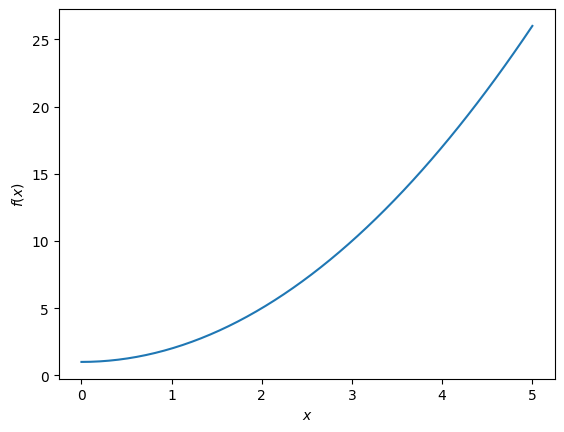

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns


def f(x): 
    return x**2 + 1

def f_prime(x):
    return 2*x

inputs = np.linspace(0.0, 5.0, num=50)
f_outs = f(inputs)
f_prime_outs = f_prime(inputs)

# Plot the function f(x)
sns.lineplot(
    data=pd.DataFrame({"$x$": inputs, "$f(x)$": f_outs}), 
    x="$x$",
    y="$f(x)$"
)

<Axes: xlabel='$x$', ylabel="$f'(x)$">

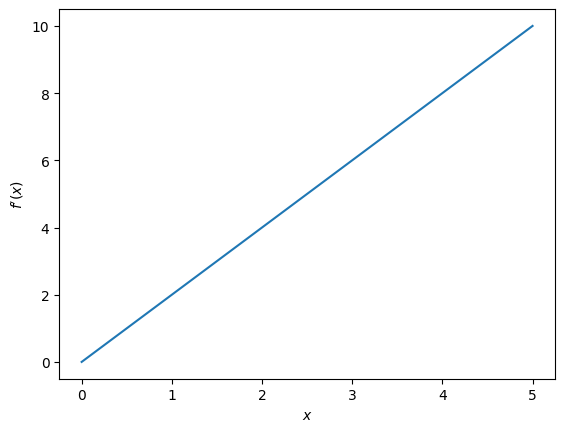

In [2]:
# Plot the gradient
sns.lineplot(
    data=pd.DataFrame({"$x$": inputs, "$f'(x)$": f_prime_outs}),
    x="$x$",
    y="$f'(x)$"
)

We can see from the second figure how much $f(x)$ will change if we change $x$ a little bit: when $x=1$, we increase $f(x)$ by two times as much; when $x=2$, we increase by 4 times as much...

We can easily extend this to functions with more than one input using *partial derivatives*. Let's put this into concrete terms as well.

Let's take the function 

$$f(x_1, x_2) = 2x^3_1 - 3x_1^2 x_2^3 + x_2^2$$

To find $\frac{\partial f}{\partial x_1}$, we just take the derivative as usual and treat the other variables as constants:

$$\frac{\partial f}{\partial x_1} = 6x^2_1 - 6x_1x_2^3$$

We can then do the same for $x_2$:

$$\frac{\partial f}{\partial x_2} = -9x_1^2x_2^2 + 2x_2$$

Tying this back to our definition of a gradient, we can see that the gradient of $f(x_1, x_2)$ is actually a vector with the same number of elements as our function has input values: 

$$\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}\right] = [6x^2_1 - 6x_1x_2^3, -9x_1^2 x_2^2 + 2x_2]$$

Let's visualize the gradient using a quiver plot, which shows the direction and magnitude of the gradient using arrows. 

Text(0.5, 1.0, 'Gradient field')

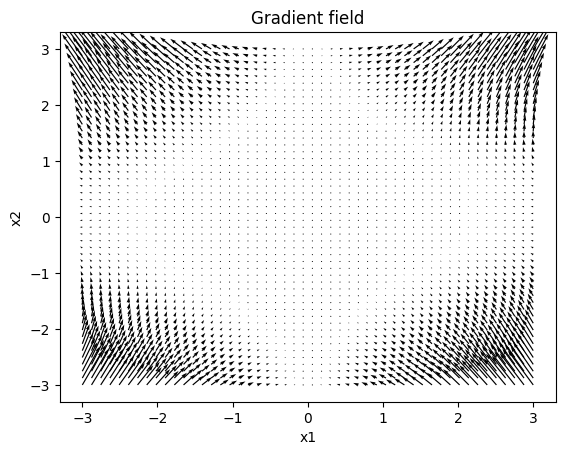

In [3]:
import matplotlib.pyplot as plt

def f_2d(x_1, x_2):
    return 2*(x_1**3) - 3*(x_1**2)*(x_2**3) + (x_2**2)

# Get negative partial derivatives
def f_prime_2d(x_1, x_2):
    return -(6*x_1**2 - 6*x_1*(x_2**3)), -(-9*(x_1**2)*(x_2**2) + 2*x_2)

x_1, x_2 = np.meshgrid(np.linspace(-3, 3, 50), np.linspace(-3, 3, 50))

df_dx1, df_dx2 = f_prime_2d(x_1, x_2)

# Make a quiver plot to show the gradient field (negative)
plt.quiver(x_1, x_2, df_dx1, df_dx2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Gradient field')

Text(0.5, 1.0, 'Gradient field')

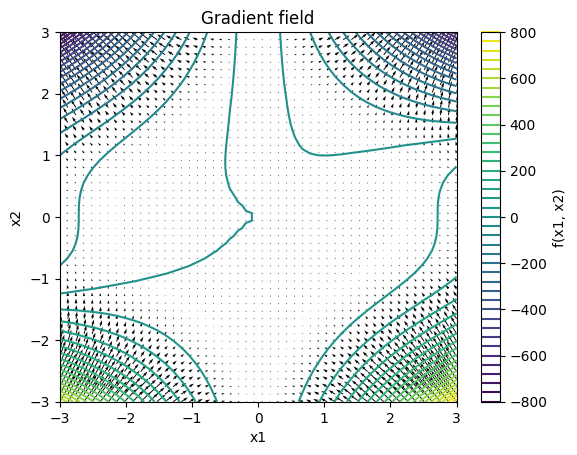

In [4]:
output = f_2d(x_1, x_2)

# Overlay a contour plot to visualize function outputs
contour = plt.contour(x_1, x_2, output, levels=50)
plt.colorbar(contour, label="f(x1, x2)")
plt.quiver(x_1, x_2, df_dx1, df_dx2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Gradient field")

We can also visualize the function in 3-d, which makes the gradient even more intuitive:

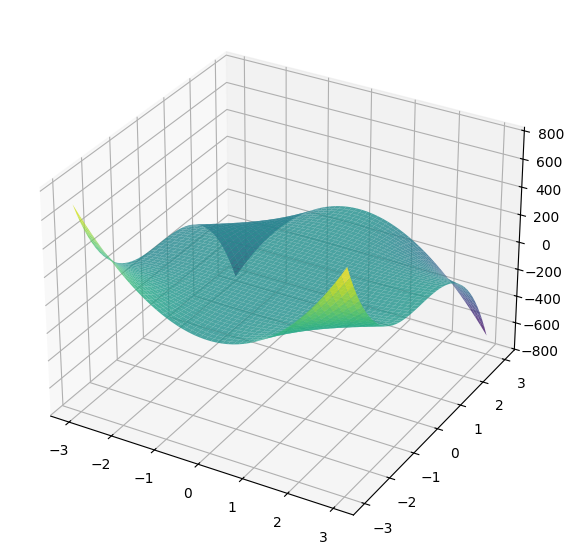

In [5]:
# Now in 3D!
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(x_1, x_2, output, cmap="viridis", alpha=0.8)

plt.show()

Pretty cool! Imagine this figure represents the loss landscape. What does the shape of the surface suggest?

Of course, this isn't limited to the 2-d case. We can generalize this to functions with $n$ inputs, like so:


$\nabla f = \left[\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, ..., \frac{\partial f}{\partial x_n}\right]$ 

For functions with multiple inputs, *the gradient is a vector of partial derivatives with respect to each input*. 

## Jacobian Matrix

But remember: ultimately, we're trying to adjust the parameters of a neural model. Think of an MLP from last lecture: some (or all) of the layers in an MLP accept multiple inputs *and* produce *multiple outputs*. How do we a calculate gradients for something like this? 

Let's take a simple linear layer as an example, ignoring the bias term and any activation function:

$$\mathbf{f}(\mathbf{x}) = \mathbf{W}\mathbf{x}$$
where 
$$\mathbf{x} \in \R^n$$
$$\mathbf{W} \in \R^{m \times n}$$

Our input $\mathbf{x}$ is $n$ dimensional, but what about our output? 

Because of the rules of matrix multiplication, $\mathbf{f}(\mathbf{x}) \in \R^m$. We have a function that not only has multiple inputs $[x_1, ... x_n]$, but that also has multiple outputs $[f_1(x_1,..., x_n), ..., f_m(x_1, ..., x_n)]$.


What is $\nabla \mathbf{f}$? 

The *Jacobian* matrix is an $m \times n$ matrix of partial derivatives: 

$$\frac{\partial{\mathbf{f}}}{\partial \mathbf{x}} = \begin{pmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n} \\
\end{pmatrix}$$

That this Jacobian is $m \times n$ and $\mathbf{W}$ is $m \times n$ is no coincidence: in our example, the $\frac{\partial \mathbf{f}}{\partial \mathbf{x}} = \mathbf{W}$! 

Try to work that out elementwise in your head for a second. This should make sense given our earlier examples. 

We won't be spending much time on Jacobians in particular, but we will be learning to use them in the next section.

## Chain Rule and Backpropagation

So far, we've only been looking at single functions on their own, whether they have one or more inputs or outputs. Neural networks, however, are *compositions of functions*. As an example, here's just one layer of an MLP: a linear transformation followed by an activation function $f$.

$$\mathbf{z} = f(\mathbf{h})$$
$$\mathbf{h} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

$\mathbf{z}$ is a function of $\mathbf{h}$, which is in turn a function of $\mathbf{x}$. We need to find a way put these pieces together. 


### Chain Rule
More calculus! 

Let's put matrices and vectors on hold for a second. What do you do when you want to find the derivative of the composition of two functions?

$$ (z \circ y)(x) = z(y(x)) $$

Chain rule!

$$\frac{dz}{dx} = \frac{dz}{dy} \frac{dy}{dx}$$

Concretely, an example with actual numbers:

$$z = 2y^2$$
$$y = 3x$$

$$\frac{dz}{dy} = 4y$$
$$\frac{dy}{dx} = 3$$
$$\frac{dz}{dx} = \frac{dz}{dy}\frac{dy}{dx} = 12y = 12(3x) = 36x$$

As you might expect, this generalizes to higher dimensional input/output as well! 

Back to our simple neural network: 

$$\mathbf{s} = f(\mathbf{h})$$
$$\mathbf{h} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

If we want to find $\frac{\partial \mathbf{s}}{\partial \mathbf{b}}$, we use the chain rule:

$$\frac{\partial \mathbf{s}}{\partial \mathbf{b}} = \frac{\partial \mathbf{s}}{\partial \mathbf{h}}\frac{\partial \mathbf{h}}{\partial \mathbf{b}}$$

For a composition of one variable functions, we multiply derivatives; for a composition of multivariable functions, we multiply Jacobians!







## Backpropagation

We won't go into the actual backpropagation ("backprop") algorithm in too much detail here, since it is a. handled automatically by any machine learning library you'll use and b. a little bit out of scope for this course. However, you should know what it is in broad strokes. 

As we've discussed, neural models can be extremely large. Backpropagation is an algorithm that makes the backward pass (computing gradients) the same time complexity as the forward pass (forward propagation, computing the output of the network). 

This is accomplished by avoiding duplicate computation: we compute the gradient of a node using the gradient with respect to all the nodes we've already visited. The chain rule makes this possible! (See slides 58-77 [here](https://web.stanford.edu/class/cs224n/slides/cs224n-spr2024-lecture03-neuralnets.pdf) for a very straightforward example.)

Instead of doing this by hand, we'll illustrate what's going on in PyTorch in the forward and backward passes, both for regular arithmetic and an MLP.

In [6]:
import torch

a = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(2.0, requires_grad=True)

c = 2*a**2 - 3*b*a

# c = 2a^2 + 3b

# dc/da = 4a + 3b = 12 - 6 = 6
# dc/db = -3a = -9

# What does PyTorch record in the computation graph?
print("c grad_fn: ", c.grad_fn)
print("One step back: ", c.grad_fn.next_functions)

# What are the gradients of a and b? 
print("Gradient of a before backward: ", a.grad)
print("Gradient of b before backward: ", b.grad)

# Perform backpropagation
c.backward()

# Check out gradients again:
print("Gradient of a after backward: ", a.grad)
print("Gradient of b after backward: ", b.grad)

c grad_fn:  <SubBackward0 object at 0x7f4db7799960>
One step back:  ((<MulBackward0 object at 0x7f4db7799540>, 0), (<MulBackward0 object at 0x7f4db77999f0>, 0))
Gradient of a before backward:  None
Gradient of b before backward:  None
Gradient of a after backward:  tensor(6.)
Gradient of b after backward:  tensor(-9.)


Here's a real example using a simple 2-layer MLP.

In [7]:
import torch
from torch import nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        h = self.fc1(x)   # h = x @ W1^T + b1
        z = F.sigmoid(h)  # z = sigmoid(h)
        y = self.fc2(z)   # y = z @ W2^T + b2
        s = F.sigmoid(y)  # s = sigmoid(y)
        return s

mlp = MLP(2, 4, 1)

x = torch.randn(2, requires_grad=True)
labels = torch.randn(1)

output = mlp(x)

# What is the gradient function for the output? 
print(output.grad_fn)


In [8]:
# Compute the loss
loss = F.mse_loss(output, labels)
print("Loss: ", loss.item()) 

# This computes gradients wrt the loss
loss.backward()

# Now, we can see all of our gradients:
for name, parameter in mlp.named_parameters():
    print(f"{name:<25} {str(parameter.grad):<100} {str(parameter.grad.size()):<10}")


Loss:  0.4588465392589569
fc1.weight                tensor([[-0.0059, -0.0091],
        [ 0.0060,  0.0094],
        [-0.0059, -0.0092],
        [-0.0002, -0.0003]]) torch.Size([4, 2])
fc1.bias                  tensor([ 0.0293, -0.0301,  0.0293,  0.0008])                                                         torch.Size([4])
fc2.weight                tensor([[0.1479, 0.1985, 0.1678, 0.2210]])                                                           torch.Size([1, 4])
fc2.bias                  tensor([0.3384])                                                                                     torch.Size([1])
